<a href="https://colab.research.google.com/github/RAJANIKANT2907/Data-Science-Projects-and-Assignments/blob/main/Decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease (1).csv to heart_disease (1) (1).csv


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB

--- Missing Values ---
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
d

/tmp/ipykernel_5567/3463802864.py:47: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang'] = df['exang'].astype(str).str.lower().replace({'false': 0, 'true': 1, 'ture': 1, '0': 0, '1': 1})



--- Optimized Model Metrics ---
Accuracy: 0.7582
Precision: 0.7692
Recall: 0.7527
F1-Score: 0.7609
ROC-AUC: 0.8246


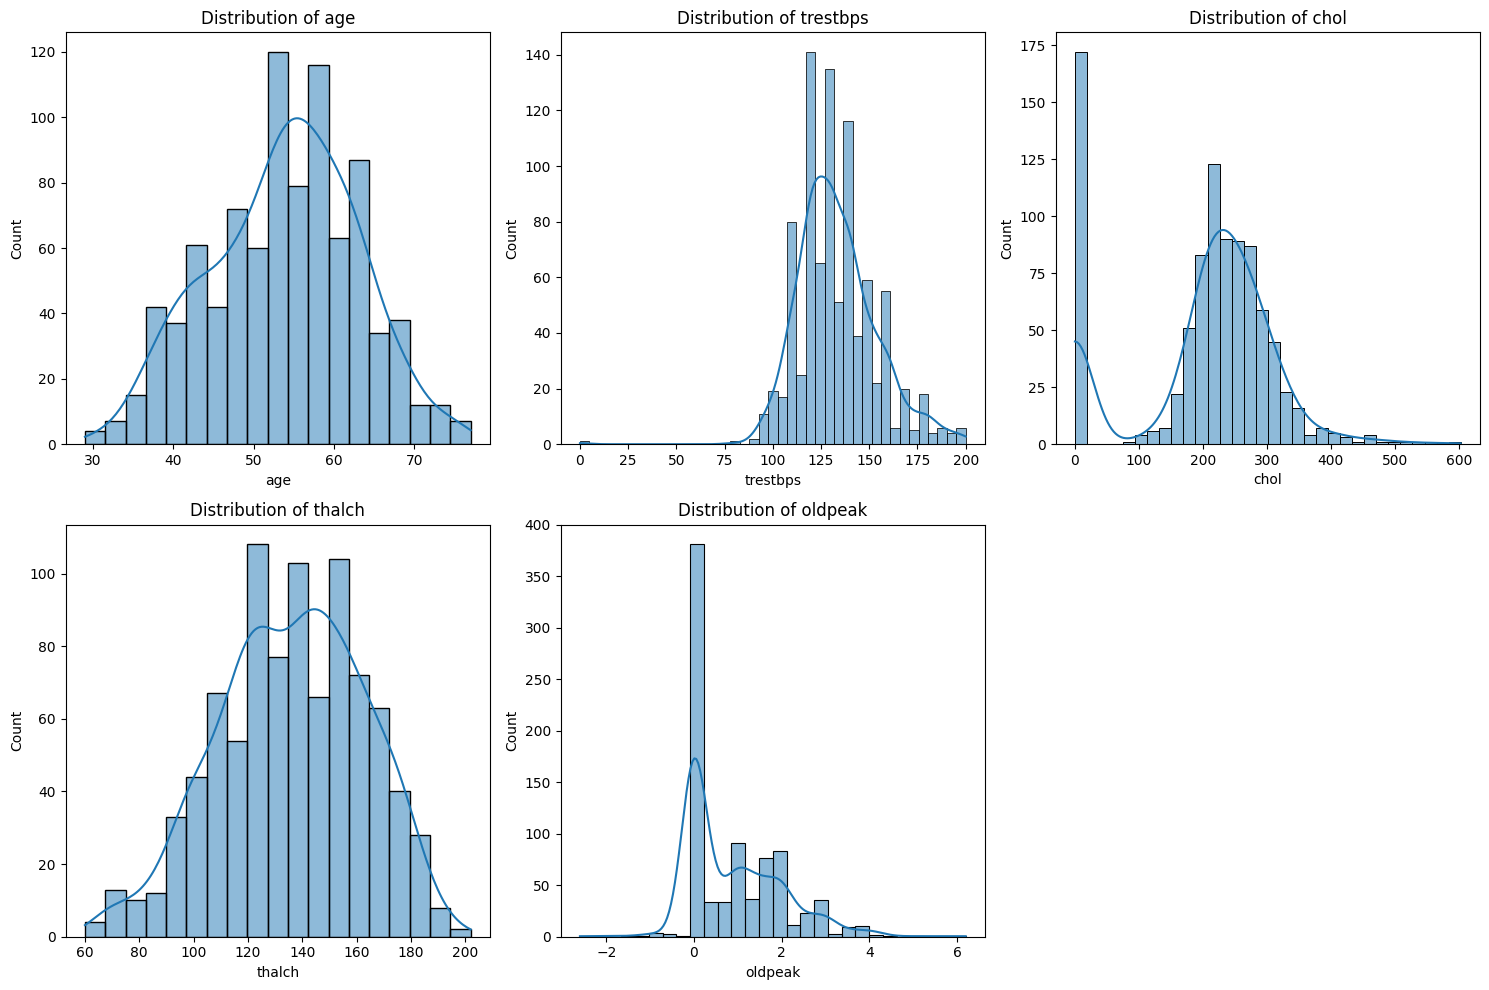

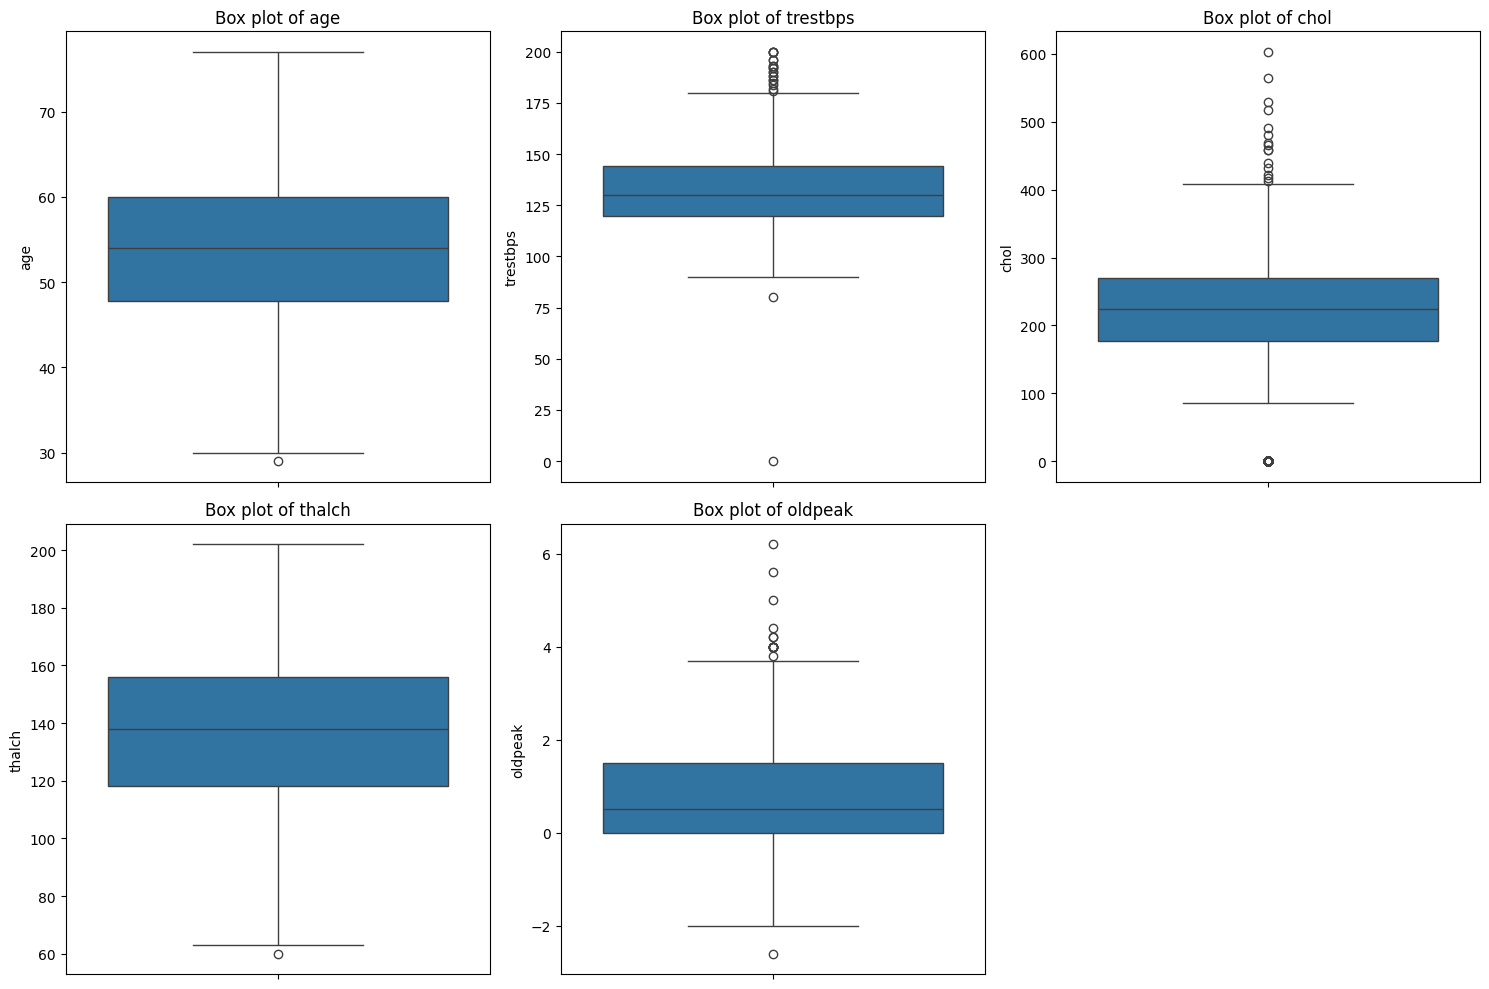

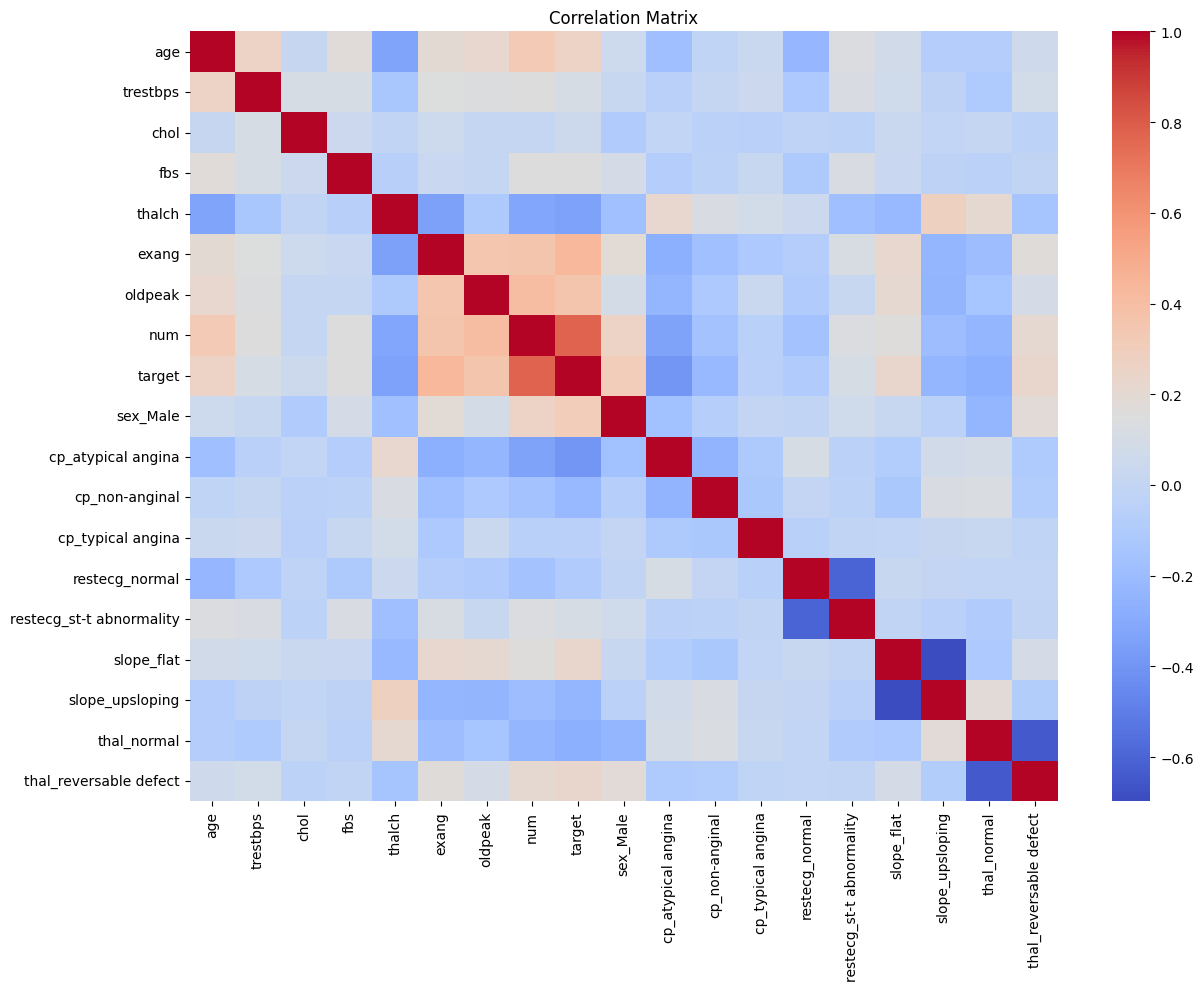

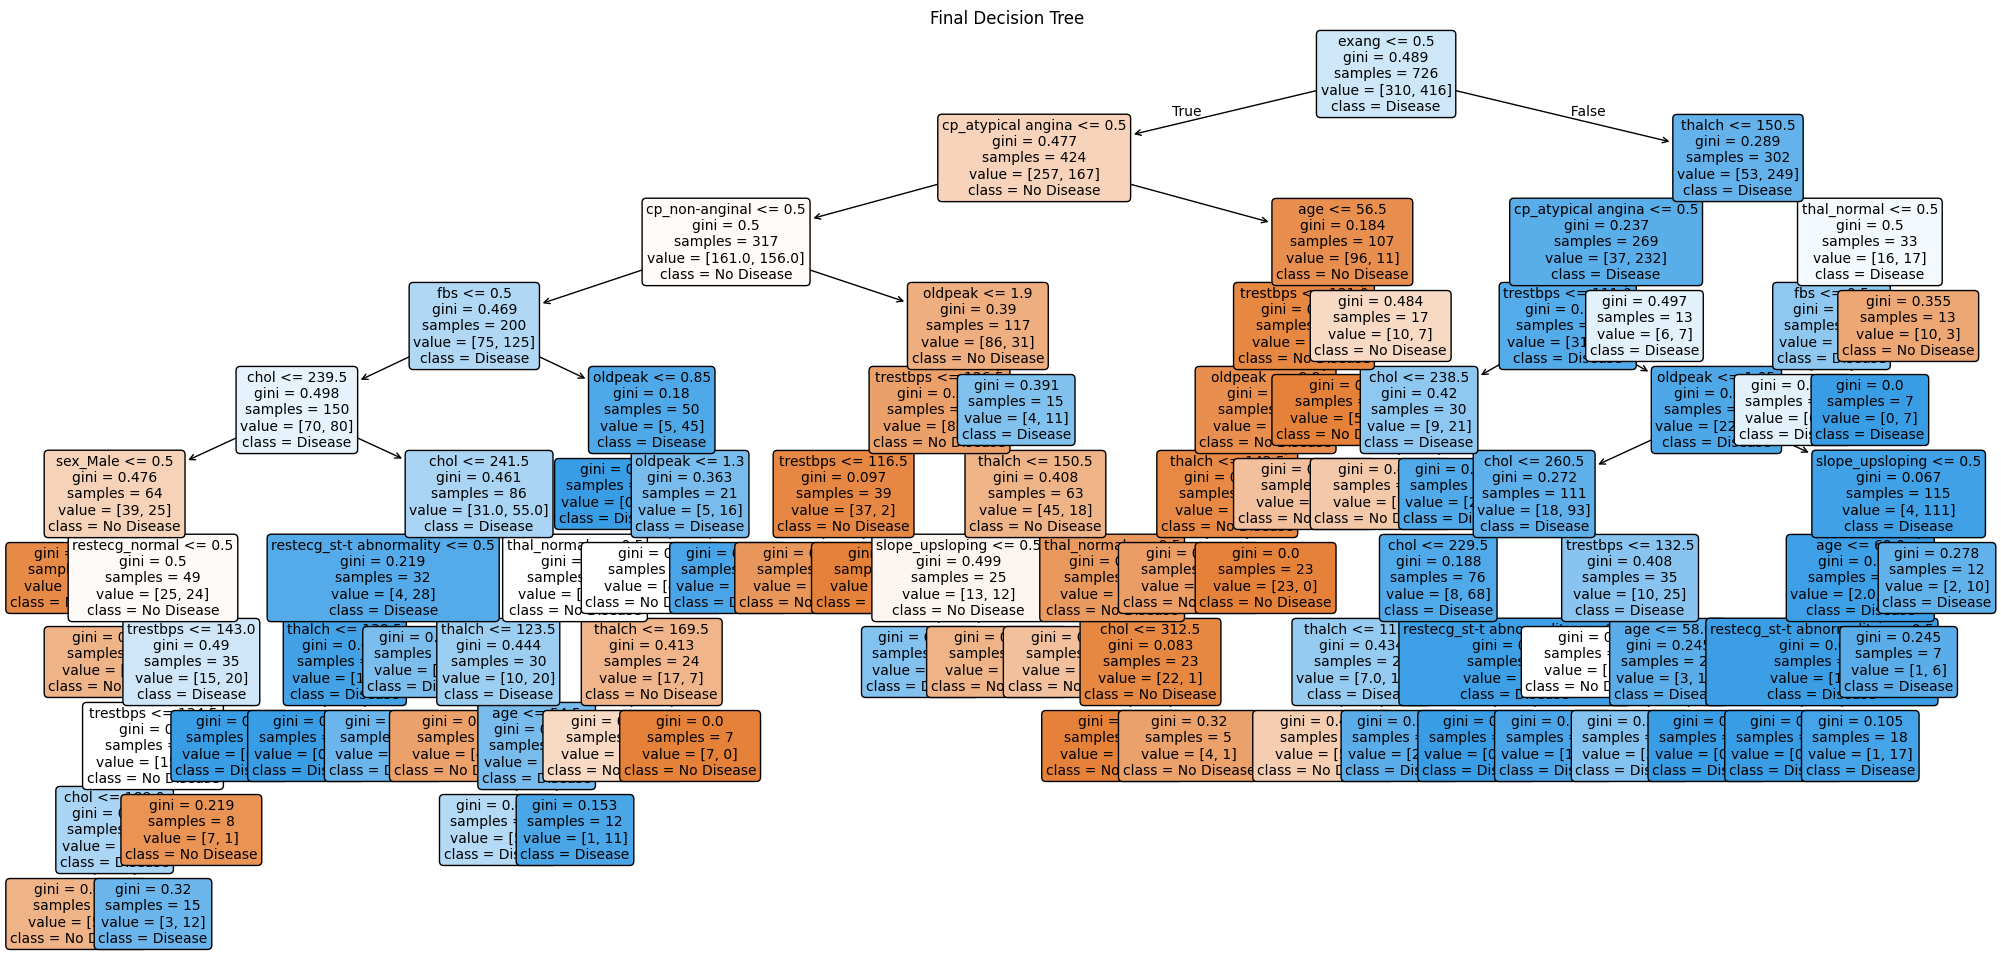

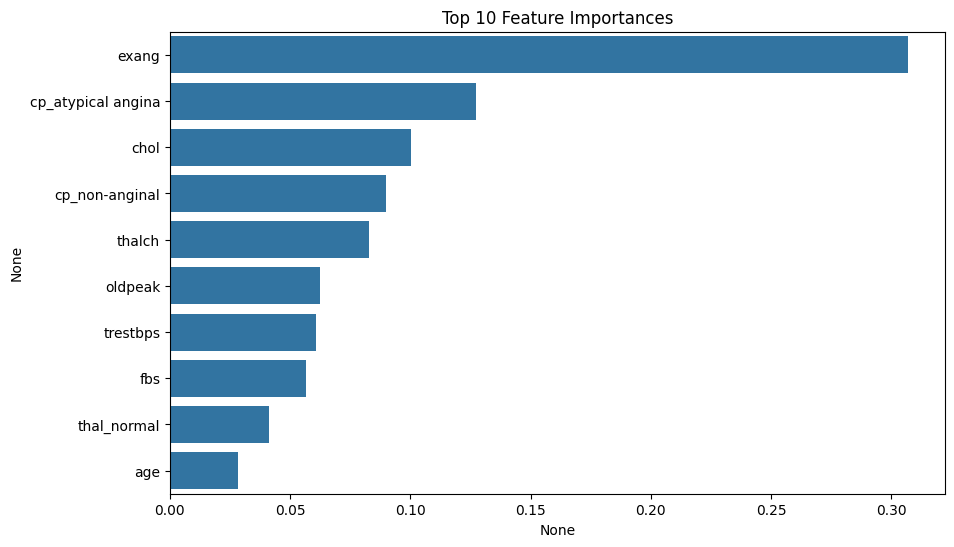

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Load the data - Corrected to load from Excel file
df = pd.read_excel('heart_disease (1).xlsx', sheet_name='Heart_disease')

# 1. EDA - Summary and Missing Values
print("--- Data Info ---")
df.info()
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 2. EDA - Visualizing Distributions (Histograms)
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('histograms.png')

# 3. EDA - Visualizing Outliers (Box Plots)
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.savefig('boxplots.png')

# 4. Data Cleaning & Feature Engineering
# Impute missing oldpeak with median
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

# Fix zero values in trestbps and chol
df.loc[df['trestbps'] == 0, 'trestbps'] = df['trestbps'].median()
median_chol = df.loc[df['chol'] > 0, 'chol'].median()
df.loc[df['chol'] == 0, 'chol'] = median_chol

# Clean exang typos
df['exang'] = df['exang'].astype(str).str.lower().replace({'false': 0, 'true': 1, 'ture': 1, '0': 0, '1': 1})
df['exang'] = pd.to_numeric(df['exang'])

# Convert fbs to int
df['fbs'] = df['fbs'].astype(int)

# Create binary target
df['target'] = (df['num'] > 0).astype(int)

# One-hot encoding
categorical_cols = ['sex', 'cp', 'restecg', 'slope', 'thal']
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 5. Correlation Matrix
plt.figure(figsize=(14, 10))
sns.heatmap(df_final.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.savefig('correlation_matrix.png')

# 6. Model Training & Tuning
X = df_final.drop(['num', 'target'], axis=1)
y = df_final['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Grid Search for best parameters
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
best_dt = grid_search.best_estimator_

# Evaluation
y_pred = best_dt.predict(X_test)
y_pred_proba = best_dt.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba)
}
print("\n--- Optimized Model Metrics ---")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# 7. Visualization of Tree and Importance
plt.figure(figsize=(25, 12))
plot_tree(best_dt, feature_names=X.columns, class_names=['No Disease', 'Disease'], filled=True, rounded=True, fontsize=10)
plt.title('Final Decision Tree')
plt.savefig('decision_tree.png')

plt.figure(figsize=(10, 6))
importances = pd.Series(best_dt.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=importances.head(10), y=importances.head(10).index)
plt.title('Top 10 Feature Importances')
plt.savefig('feature_importance.png')

Interview Answers
1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

max_depth: Limits how deep the tree grows. Deep trees can model complex relationships but are prone to overfitting; shallow trees are simpler but may underfit.

min_samples_split: The minimum number of observations required to split a node. Higher values prevent the model from learning from tiny noise-driven patterns.

min_samples_leaf: The minimum number of samples allowed in a leaf node. It acts as a smoothing parameter to ensure each prediction is based on a statistically significant amount of data.

criterion: The mathematical metric used to evaluate a split (e.g., Gini Impurity or Entropy).

2. What is the difference between Label encoding and One-hot encoding?

Label Encoding: Assigns each category a number (e.g., Red=1, Green=2, Blue=3). It is best for ordinal data where the order matters. If used on nominal data, the model might incorrectly assume that Blue is "greater than" Red.

One-hot Encoding: Creates a separate column for each category with binary values (0 or 1). It is best for nominal data (like colors or gender) because it treats all categories as independent and equal, though it increases the dataset's size.